In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
dataset_dir = "flowers"

img_size = (299, 299)
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4289 images belonging to 18 classes.
Found 1068 images belonging to 18 classes.


In [ ]:
densenet_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

for layer in densenet_model.layers:
    layer.trainable = False

num_classes = len(train_generator.class_indices)

model = models.Sequential([
    densenet_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 155s 5us/step


In [ ]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=valid_generator
)

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5986 - loss: 1.3333

C:\Users\Melih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


135/135 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.5991 - loss: 1.3314 - val_accuracy: 0.8006 - val_loss: 0.6564
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.7733 - loss: 0.6806 - val_accuracy: 0.8567 - val_loss: 0.4394
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.8229 - loss: 0.5165 - val_accuracy: 0.8652 - val_loss: 0.4211
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8545 - loss: 0.4381 - val_accuracy: 0.8858 - val_loss: 0.3642
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.8641 - loss: 0.4061 - val_accuracy: 0.8820 - val_loss: 0.3508


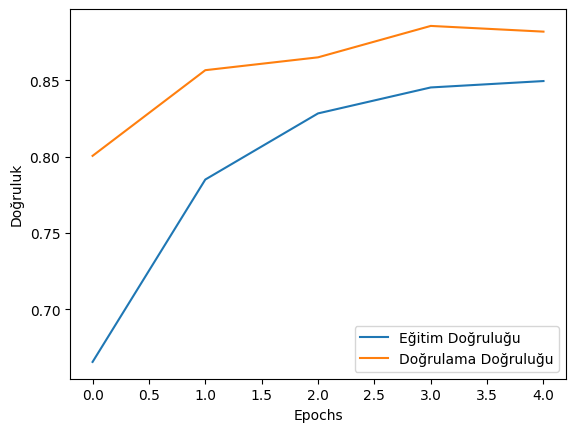

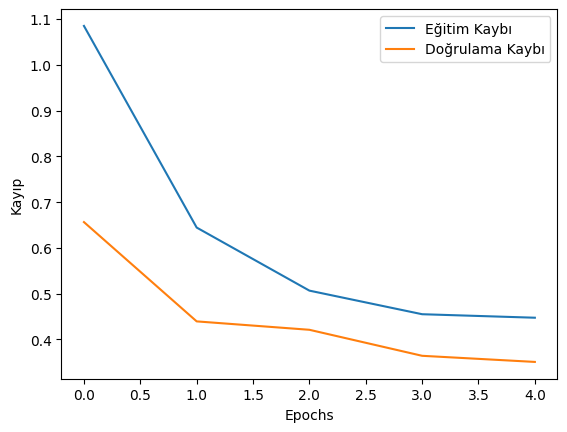

In [ ]:
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()
plt.show()

In [ ]:
test_generator = test_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Doğruluğu: {test_acc * 100:.2f}%")

Found 5357 images belonging to 18 classes.
168/168 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9195 - loss: 0.2557
Test Doğruluğu: 91.62%


In [ ]:
model.save('densenet121_Model.h5')